# fft_band_stepwise 候補特徴の診断 — 分散・含水率関係・特徴間相関

[fft_band_stepwise_features](../docs/fft_band_stepwise_features.md) で定義された
**候補特徴 = 9バンド × 8統計量 = 72本** を行単位(リーク無し)で再構成し、3つの観点で可視化する。

1. **各特徴の分散** — 情報量が無い(ほぼ定数)特徴を洗い出す
2. **含水率(MC)との関係** — 各特徴の|Pearson r|と、上位特徴の散布図
3. **特徴量同士の相関** — 72×72相関ヒートマップと冗長(高相関)ペア

doc確定の **5特徴**(LOSO macro-RMSE=17.2の楽観値)を各図でハイライトする。
統計量・前処理は全て行単位なので特徴行列はリーク無しで全train一括計算できる(doc準拠)。

In [2]:
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
matplotlib.rcParams['font.family'] = ['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110

tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
wn_cols = [c for c in tr.columns if c not in ['sample number','species number','樹種','含水率']]
wn = np.array([float(c) for c in wn_cols]); wl = 1e7 / wn          # 波数 cm-1 -> 波長 nm
order = np.argsort(wl); nm = wl[order]                             # nm昇順
Xraw = tr[wn_cols].values.astype(float)[:, order]                 # 生スペクトル(nm昇順)
mc = tr['含水率'].values                                           # 含水率 [%]
sp = tr['樹種'].values
print('train', tr.shape, '| 点数', len(nm), '| nm範囲 %.0f-%.0f' % (nm.min(), nm.max()))
print('含水率 %.1f-%.1f%% | 樹種 %d種' % (mc.min(), mc.max(), len(np.unique(sp))))

train (1270, 1559) | 点数 1555 | nm範囲 1001-2500
含水率 0.8-298.6% | 樹種 13種


## 候補特徴 72本の再構成

docのバンド表(9バンド)× 統計量8種。前処理 `snv_*`=SNV後にSG / `raw_*`=生波形に直接SG、
ベースは「元」=生スペクトル / 「弱マスク」=逆FFTで中心±15%だけ残す平滑化 `fft_denoise(keep_frac=0.15)`。

In [3]:
# --- 前処理関数(全て行単位=リーク無し) ---
def snv(M): return (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-8)
def fft_denoise(X, keep_frac=0.15):                   # 弱マスク平滑化(doc準拠)
    n = X.shape[1]; ifg = np.fft.fftshift(np.fft.ifft(X, axis=1), axes=1); c = n // 2
    r = max(1, int(round(keep_frac * n / 2))); ifg[:, :c-r] = 0; ifg[:, c+r+1:] = 0
    return np.fft.fft(np.fft.ifftshift(ifg, axes=1), axis=1).real
sg = lambda M, d: savgol_filter(M, 11, 2, deriv=d, axis=1)

weak = fft_denoise(Xraw, 0.15)
SRC = {                                               # 各バンドが参照する前処理済みスペクトル
    'snv_orig':     snv(Xraw),
    'sg1_snv_orig': sg(snv(Xraw), 1),
    'sg1_snv_weak': sg(snv(weak), 1),
    'sg2_snv_weak': sg(snv(weak), 2),
    'raw_weak':     weak,
    'sg2_weak':     sg(weak, 2),
}
# バンド名 -> (参照ソース, 帯域nm)  ※docの9バンド表
BANDS = {
    'snv_1430_1470':     ('snv_orig',     (1430, 1470)),
    'snv_sg1_2000_2100': ('sg1_snv_orig', (2000, 2100)),
    'snv_sg1_2400_2480': ('sg1_snv_orig', (2400, 2480)),
    'snv_sg1_1650_1670': ('sg1_snv_weak', (1650, 1670)),
    'snv_sg2_1910_1940': ('sg2_snv_weak', (1910, 1940)),
    'snv_sg1_2020_2100': ('sg1_snv_weak', (2020, 2100)),
    'raw_1050_1300':     ('raw_weak',     (1050, 1300)),
    'raw_sg2_1430_1470': ('sg2_weak',     (1430, 1470)),
    'raw_sg2_1600_1700': ('sg2_weak',     (1600, 1700)),
}

In [4]:
# --- 統計量8種(バンド内ベクトル B[n,k], 波長 w[k] から行単位) ---
def _slope(B, w): w0 = w - w.mean(); return (B * w0).sum(1) / (w0**2).sum()
def _cr_depth(B, w):                                  # 両端直線からの最大へこみ
    t = (w - w[0]) / (w[-1] - w[0]); line = B[:, [0]] * (1-t)[None] + B[:, [-1]] * t[None]
    return (line - B).max(1)
STATS = {
    'mean':    lambda B, w: B.mean(1),
    'std':     lambda B, w: B.std(1),
    'min':     lambda B, w: B.min(1),
    'max':     lambda B, w: B.max(1),
    'amp':     lambda B, w: B.max(1) - B.min(1),
    'absmax':  lambda B, w: np.abs(B).max(1),
    'slope':   _slope,
    'cr_depth':_cr_depth,
}

cols, names = [], []
for bname, (src, (lo, hi)) in BANDS.items():
    m = (nm >= lo) & (nm <= hi); B, w = SRC[src][:, m], nm[m]
    for sname, f in STATS.items():
        cols.append(f(B, w)); names.append(f'{bname}|{sname}')
F = pd.DataFrame(np.column_stack(cols), columns=names)        # n × 72

FINAL5 = ['snv_sg1_2000_2100|max', 'snv_sg1_2020_2100|cr_depth', 'raw_sg2_1430_1470|min',
          'snv_1430_1470|slope', 'snv_sg1_2000_2100|cr_depth']     # doc確定5特徴
print('特徴行列', F.shape, '| 確定5特徴:', all(f in F.columns for f in FINAL5))

特徴行列 (1270, 72) | 確定5特徴: True


## 1. 各特徴の分散

統計量ごとにスケールが大きく異なるため、生の分散と、Z標準化前の生スケールでの分散を併記しても
解釈しづらい。ここでは**特徴ごとに分散そのもの**(対数軸)を示し、加えて
**変動係数的に「ほぼ定数=情報量ゼロ」な特徴**(分散が極端に小さい)を洗い出す。

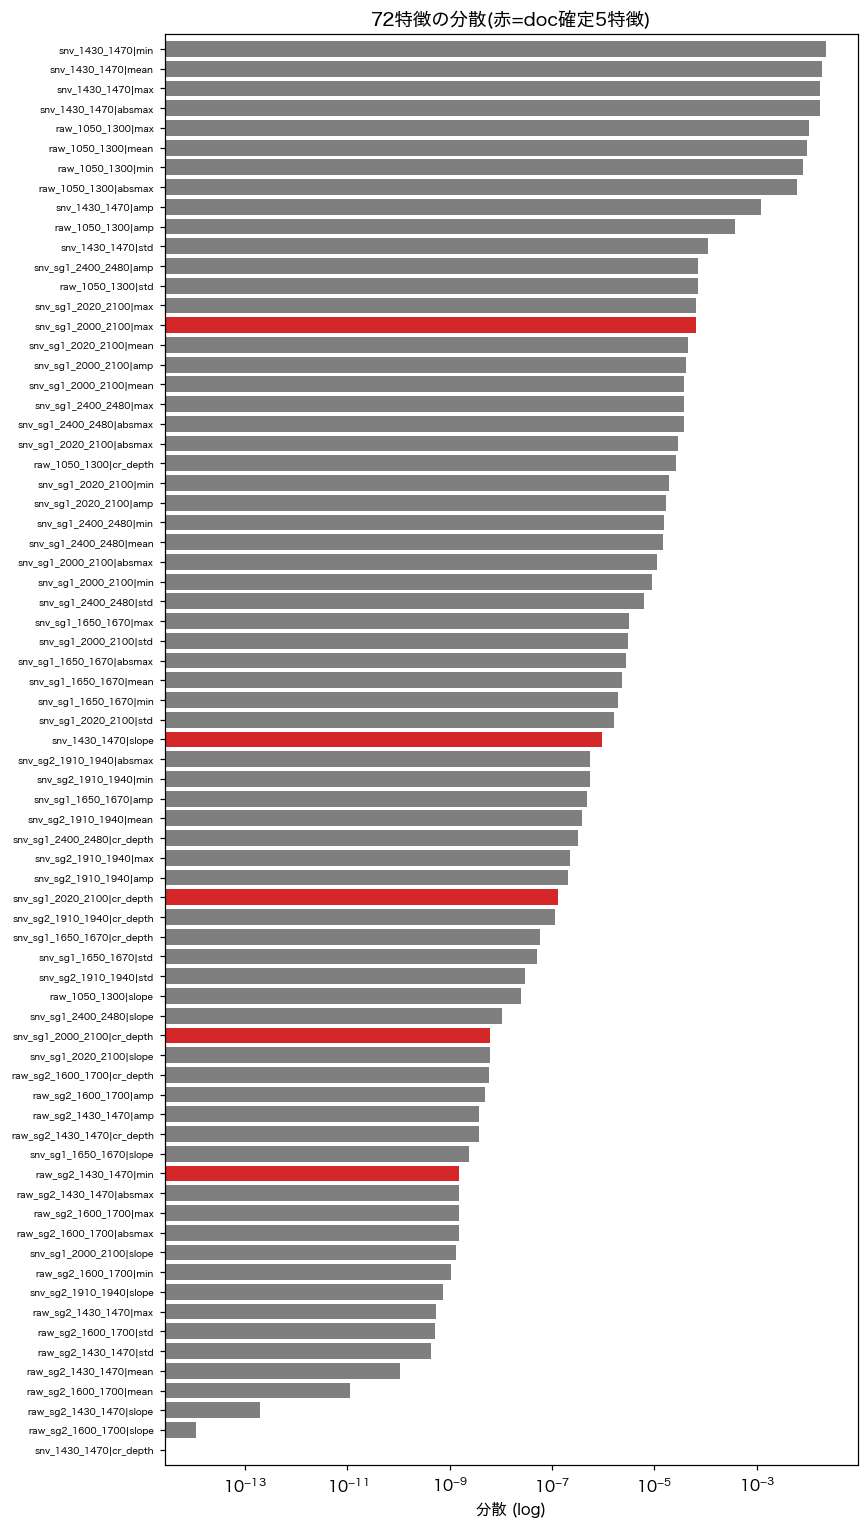

分散が極端に小さい(ほぼ定数の疑い)特徴: ['snv_1430_1470|cr_depth', 'raw_sg2_1600_1700|slope', 'raw_sg2_1430_1470|slope', 'raw_sg2_1600_1700|mean', 'raw_sg2_1430_1470|mean', 'raw_sg2_1430_1470|std', 'raw_sg2_1600_1700|std', 'raw_sg2_1430_1470|max', 'snv_sg2_1910_1940|slope']


In [5]:
var = F.var().sort_values()
colors = ['tab:red' if n in FINAL5 else 'tab:gray' for n in var.index]
fig, ax = plt.subplots(figsize=(8, 14))
ax.barh(range(len(var)), var.values, color=colors)
ax.set_yticks(range(len(var))); ax.set_yticklabels(var.index, fontsize=6)
ax.set_xscale('log'); ax.set_xlabel('分散 (log)'); ax.set_title('72特徴の分散(赤=doc確定5特徴)')
ax.margins(y=0.005); plt.tight_layout(); plt.show()

near_const = var[var < var.median() * 1e-3]
print('分散が極端に小さい(ほぼ定数の疑い)特徴:', list(near_const.index) or 'なし')

## 2. 含水率(MC)との関係

各特徴と含水率の **Pearson相関 r** を見る。バーは|r|、符号は色で示す。
確定5特徴がどの位置にあるかを確認し、上位特徴については散布図で線形性/外れ値を見る。

/Users/haru_home/Competiton/nir-spectrum/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/haru_home/Competiton/nir-spectrum/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


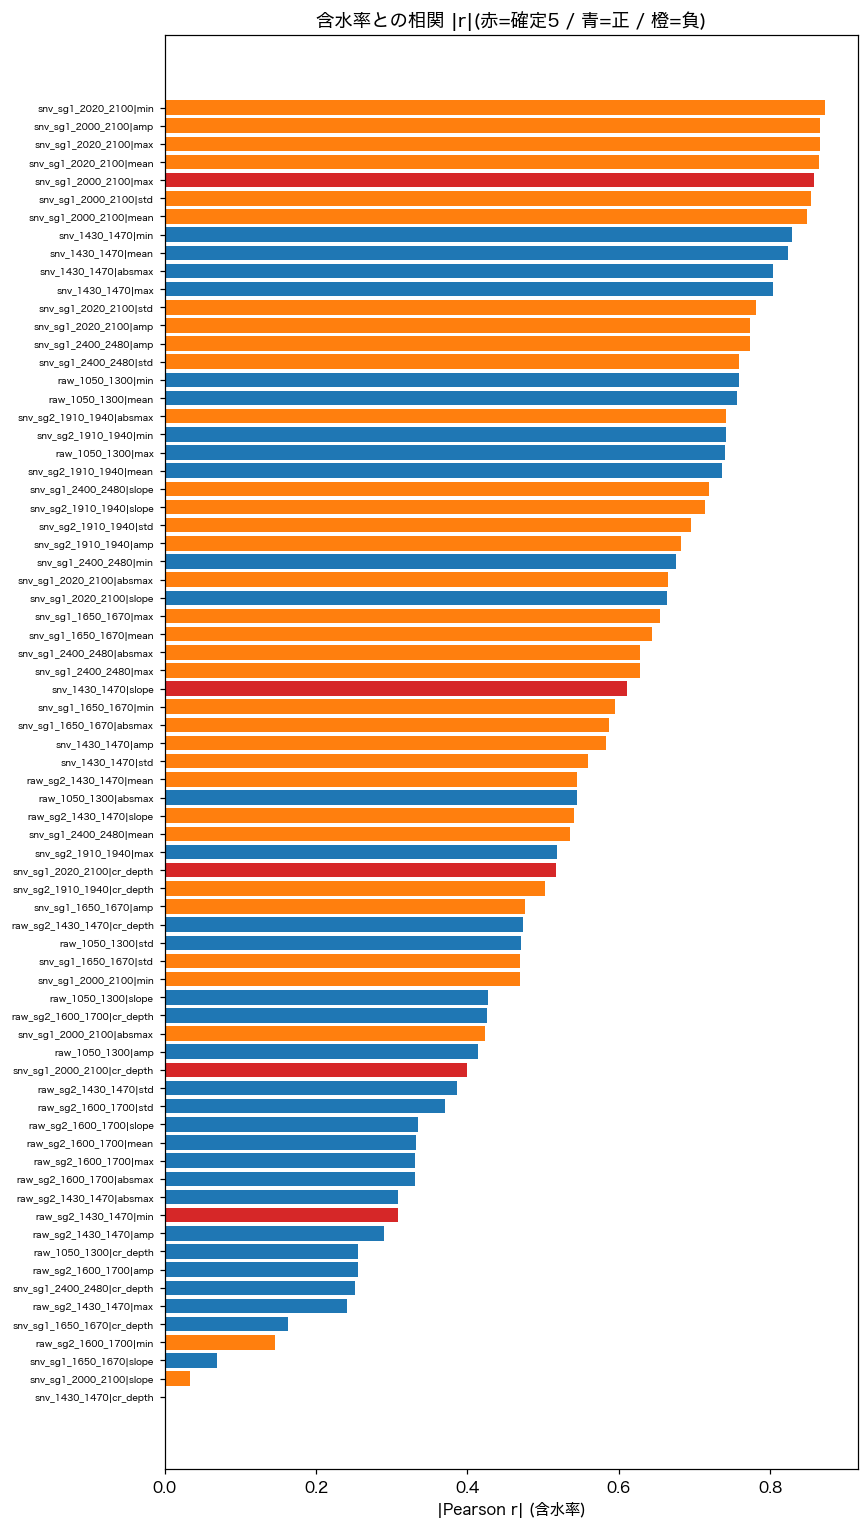

|r|上位5:
snv_sg1_2020_2100|min    -0.872
snv_sg1_2000_2100|amp    -0.866
snv_sg1_2020_2100|max    -0.866
snv_sg1_2020_2100|mean   -0.864
snv_sg1_2000_2100|max    -0.858
dtype: float64


In [6]:
r = F.corrwith(pd.Series(mc, index=F.index)).fillna(0)
r_sorted = r.reindex(r.abs().sort_values(ascending=False).index)
colors = ['tab:red' if n in FINAL5 else ('tab:blue' if r_sorted[n] >= 0 else 'tab:orange')
          for n in r_sorted.index]
fig, ax = plt.subplots(figsize=(8, 14))
ax.barh(range(len(r_sorted)), r_sorted.abs().values, color=colors)
ax.set_yticks(range(len(r_sorted))); ax.set_yticklabels(r_sorted.index, fontsize=6)
ax.invert_yaxis(); ax.set_xlabel('|Pearson r| (含水率)')
ax.set_title('含水率との相関 |r|(赤=確定5 / 青=正 / 橙=負)')
plt.tight_layout(); plt.show()
print('|r|上位5:'); print(r_sorted.head(5).round(3))

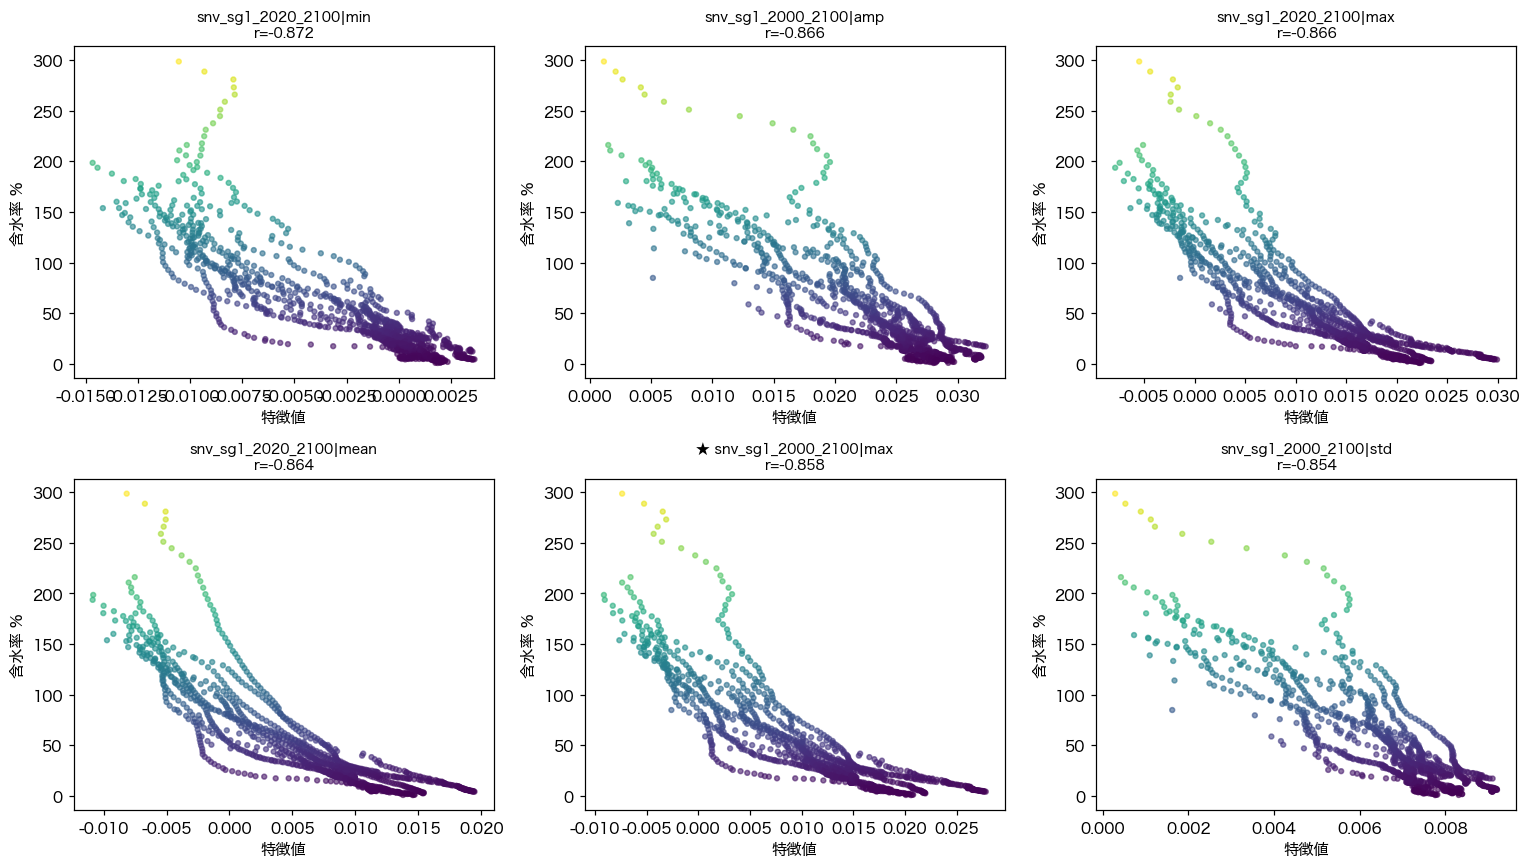

In [7]:
# 上位相関6特徴の散布図(色=含水率)。確定5特徴はタイトルに★
top6 = r.abs().sort_values(ascending=False).head(6).index
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, n in zip(axes.ravel(), top6):
    ax.scatter(F[n], mc, s=10, c=mc, cmap='viridis', alpha=0.6)
    star = '★ ' if n in FINAL5 else ''
    ax.set_title(f'{star}{n}\nr={r[n]:.3f}', fontsize=9)
    ax.set_xlabel('特徴値'); ax.set_ylabel('含水率 %')
plt.tight_layout(); plt.show()

## 3. 特徴量同士の相関

72特徴間のPearson相関行列。**冗長(高相関)な特徴群**はモデルにとって重複情報であり、
doc が「全72投入=18.82より絞った5特徴=17.2が良い」とした背景でもある。
階層クラスタ順に並べ替えて相関ブロックを見やすくする。

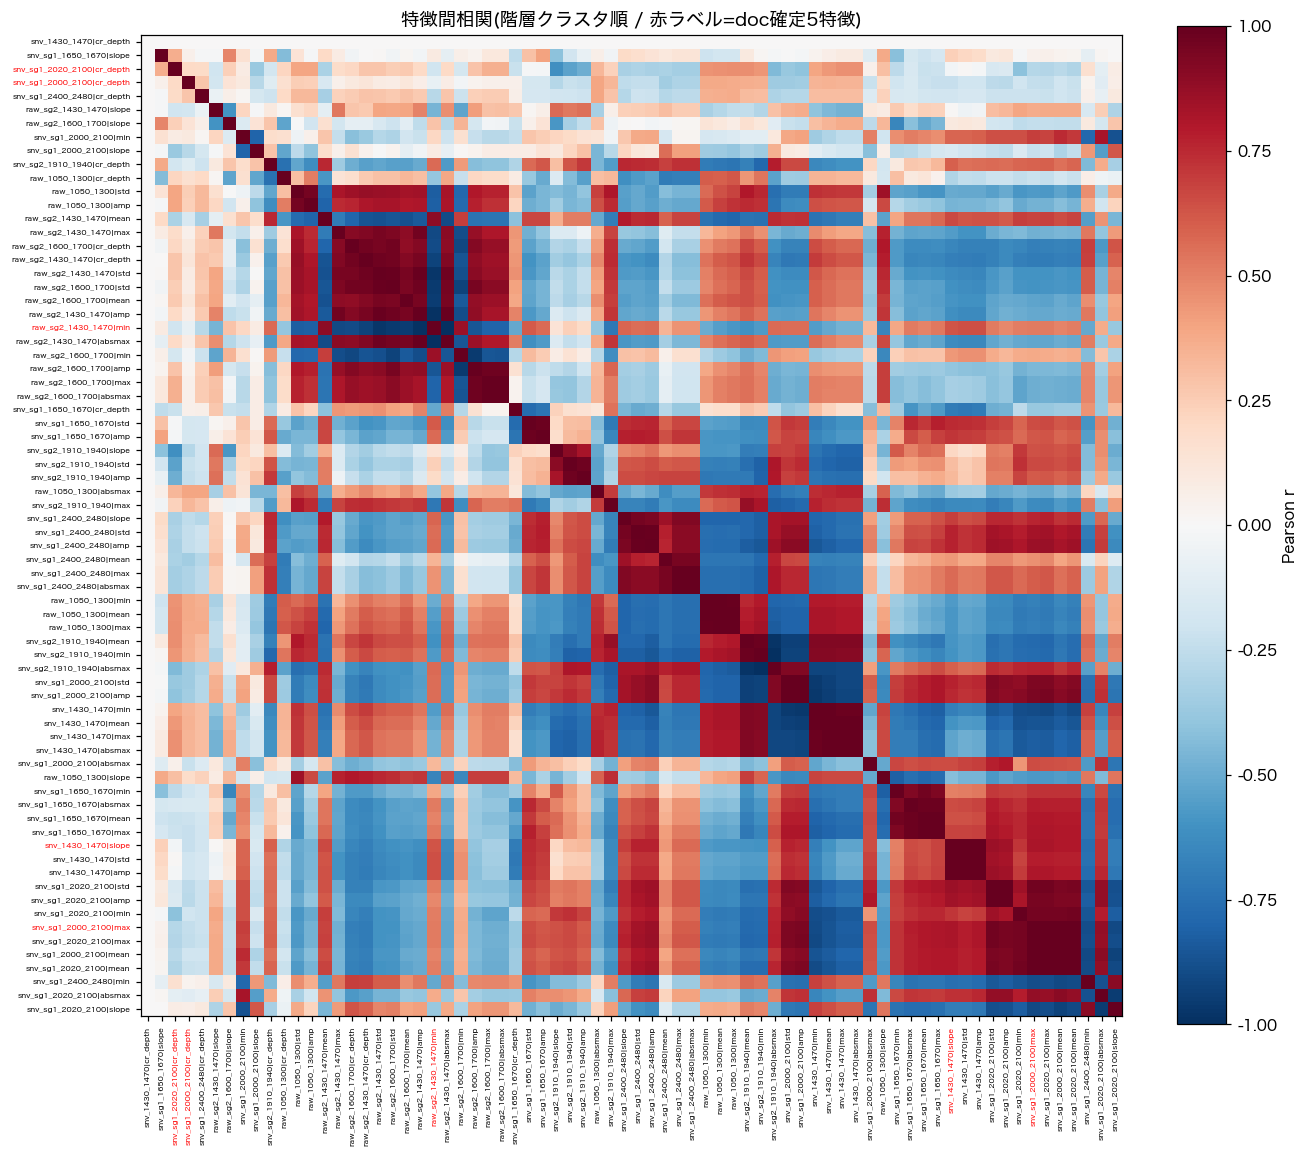

In [8]:
corr = F.corr().fillna(0)
# 階層クラスタで並べ替え
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
d = squareform(1 - corr.abs().values, checks=False)
ordr = leaves_list(linkage(d, method='average'))
cc = corr.iloc[ordr, ordr]

fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cc.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cc))); ax.set_xticklabels(cc.columns, fontsize=5, rotation=90)
ax.set_yticks(range(len(cc))); ax.set_yticklabels(cc.index, fontsize=5)
for i, n in enumerate(cc.columns):                       # 確定5特徴の目盛りを赤字に
    if n in FINAL5:
        ax.get_xticklabels()[i].set_color('red'); ax.get_yticklabels()[i].set_color('red')
fig.colorbar(im, ax=ax, fraction=0.046, label='Pearson r')
ax.set_title('特徴間相関(階層クラスタ順 / 赤ラベル=doc確定5特徴)')
plt.tight_layout(); plt.show()

In [11]:
# 高相関ペア(|r|>=0.90)= 冗長候補
cu = corr.where(np.triu(np.ones(corr.shape, bool), 1))
pairs = (cu.abs().stack().sort_values(ascending=False))
pairs = pairs[pairs >= 0.90]
print('|r|>=0.90 の冗長ペア数:', len(pairs))
for (a, b), v in pairs.head(20).items():
    print(f'  {v:+.3f}  {a}  <->  {b}')

# 確定5特徴どうしの相関(互いに独立か)
print('\n確定5特徴間の相関:')
print(corr.loc[FINAL5, FINAL5].round(2))

|r|>=0.90 の冗長ペア数: 145
  +1.000  snv_1430_1470|max  <->  snv_1430_1470|absmax
  +1.000  snv_sg1_2400_2480|max  <->  snv_sg1_2400_2480|absmax
  +1.000  raw_sg2_1430_1470|min  <->  raw_sg2_1430_1470|absmax
  +1.000  snv_sg2_1910_1940|min  <->  snv_sg2_1910_1940|absmax
  +1.000  raw_sg2_1600_1700|max  <->  raw_sg2_1600_1700|absmax
  +0.999  snv_sg1_2000_2100|max  <->  snv_sg1_2020_2100|max
  +0.998  snv_sg1_2000_2100|max  <->  snv_sg1_2020_2100|mean
  +0.998  raw_1050_1300|mean  <->  raw_1050_1300|max
  +0.998  snv_sg1_2000_2100|mean  <->  snv_sg1_2020_2100|mean
  +0.997  snv_1430_1470|std  <->  snv_1430_1470|amp
  +0.997  snv_sg1_2020_2100|mean  <->  snv_sg1_2020_2100|max
  +0.996  snv_1430_1470|mean  <->  snv_1430_1470|absmax
  +0.996  snv_1430_1470|mean  <->  snv_1430_1470|max
  +0.996  snv_sg1_2000_2100|std  <->  snv_sg1_2000_2100|amp
  +0.996  raw_1050_1300|mean  <->  raw_1050_1300|min
  +0.995  snv_sg1_2000_2100|mean  <->  snv_sg1_2000_2100|max
  +0.994  snv_1430_1470|std  <->  snv_1

## 4. 共線形性に基づく特徴削減(|r|≥0.97)

|r|≥0.97 の共線形ペア(41組)から冗長特徴を貪欲法で除去する。
各ペアのうち **含水率との|r|が低い方** を落とし、doc確定5特徴は優先保持する。
相関の強いペアから順に処理し、残存特徴間に |r|≥0.97 が無くなるまで繰り返す。

In [12]:
TH = 0.90
absmc = F.corrwith(pd.Series(mc, index=F.index)).abs().fillna(0)   # 含水率との|r|
hp = corr.where(np.triu(np.ones(corr.shape, bool), 1)).abs().stack()
hp = hp[hp >= TH].sort_values(ascending=False)                    # 共線形ペア(強い順)

# 貪欲除去: 確定5特徴を最優先で残し、次に含水率との|r|が高い方を残す
keep_key = lambda f: (f in FINAL5, absmc[f])
dropped = set()
for (a, b), v in hp.items():
    if a in dropped or b in dropped:
        continue
    dropped.add(a if keep_key(a) < keep_key(b) else b)            # 弱い方を除去
remain = [c for c in F.columns if c not in dropped]

cr2 = F[remain].corr().abs().values
print(f'共線形ペア(|r|≥{TH}): {len(hp)}組 → 除去 {len(dropped)}本 / 残存 {len(remain)}本')
print('残存間で|r|≥%.2fのペア:' % TH, int((cr2[np.triu_indices(len(remain), 1)] >= TH).sum()),
      '| 確定5特徴 全残存:', all(f in remain for f in FINAL5))
print('\n=== 残った特徴 (★=doc確定5) ===')
for c in remain:
    print(('★ ' if c in FINAL5 else '  ') + f'{c}   (MC|r|={absmc[c]:.2f})')
print('\n=== 除去した特徴 ===')
for c in sorted(dropped):
    print('  ' + c)

共線形ペア(|r|≥0.9): 145組 → 除去 41本 / 残存 31本
残存間で|r|≥0.90のペア: 0 | 確定5特徴 全残存: True

=== 残った特徴 (★=doc確定5) ===
★ snv_1430_1470|slope   (MC|r|=0.61)
  snv_1430_1470|cr_depth   (MC|r|=0.00)
  snv_sg1_2000_2100|min   (MC|r|=0.47)
★ snv_sg1_2000_2100|max   (MC|r|=0.86)
  snv_sg1_2000_2100|absmax   (MC|r|=0.42)
  snv_sg1_2000_2100|slope   (MC|r|=0.03)
★ snv_sg1_2000_2100|cr_depth   (MC|r|=0.40)
  snv_sg1_2400_2480|min   (MC|r|=0.67)
  snv_sg1_2400_2480|amp   (MC|r|=0.77)
  snv_sg1_2400_2480|cr_depth   (MC|r|=0.25)
  snv_sg1_1650_1670|max   (MC|r|=0.65)
  snv_sg1_1650_1670|amp   (MC|r|=0.48)
  snv_sg1_1650_1670|slope   (MC|r|=0.07)
  snv_sg1_1650_1670|cr_depth   (MC|r|=0.16)
  snv_sg2_1910_1940|min   (MC|r|=0.74)
  snv_sg2_1910_1940|max   (MC|r|=0.52)
  snv_sg2_1910_1940|slope   (MC|r|=0.71)
  snv_sg2_1910_1940|cr_depth   (MC|r|=0.50)
  snv_sg1_2020_2100|absmax   (MC|r|=0.66)
★ snv_sg1_2020_2100|cr_depth   (MC|r|=0.52)
  raw_1050_1300|std   (MC|r|=0.47)
  raw_1050_1300|min   (MC|r|=0.76)
  raw_1050_1

/Users/haru_home/Competiton/nir-spectrum/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/haru_home/Competiton/nir-spectrum/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## まとめの読み方

- **分散**: ほぼ定数の特徴があれば標準化後も無情報。確定5特徴が極端に低分散でないことを確認。
- **含水率相関**: 単変量|r|が高い特徴と、stepwiseで選ばれた確定5特徴は必ずしも一致しない
  (stepwiseは**残差への寄与**で選ぶため)。`cr_depth`系が水バンド深さとして効きやすい。
- **特徴間相関**: 同一バンド由来や同系統前処理は高相関ブロックを作る。確定5特徴が互いに低相関なら
  相補的=絞り込みが妥当だった裏付け。
- 注意: doc記載の通り、確定5特徴の選択は全trainを見た**楽観値**。ここでの相関も全trainでの値であり、
  外挿(LOSO)性能とは別物。詳細は [fft_band_stepwise_features](../docs/fft_band_stepwise_features.md)。